# California Housing — EDA (MLE-style)

**Goal:** Understand the dataset, document decisions, and produce a clear **training plan**.  

- Date: 11-02-2026
- Project folder: `mle/`


## 01 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(palette='bright', style="white")

## 02 — Load data

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/housing.csv")
TARGET = "median_house_value"


df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 03 — Data dictionary (light)

- `longitude`: A measure of how far west a house is; a higher value is farther west
- `latitude`: A measure of how far north a house is; a higher value is farther north
- `housing_median_age`: Median age of a house within a block; a lower number is a newer building
- `total_rooms`: Total number of rooms within a block
- `total_bedrooms`: Total number of bedrooms within a block
- `population`: Total number of people residing within a block
- `households`: Total number of households, a group of people residing within a home unit, for a block
- `median_income`: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
- `ocean_proximity`: Location of the house w.r.t ocean/sea
- `median_house_value` (TARGET): Median house value for households within a block (measured in US Dollars)

source: https://www.kaggle.com/datasets/camnugent/california-housing-prices

## 04 — Sanity checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 05 — Data quality

In [6]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_porcentage"] = (missing["missing_count"] / len(df) * 100).round(3)
missing.sort_values("missing_count", ascending=False).head(20)

,missing_count,missing_porcentage
total_bedrooms,207,1.003
longitude,0,0.000
latitude,0,0.000
housing_median_age,0,0.000
total_rooms,0,0.000
population,0,0.000
households,0,0.000
median_income,0,0.000
median_house_value,0,0.000
ocean_proximity,0,0.000


In [7]:
df.duplicated().sum()

np.int64(0)

### 5.1 — Missing analysis for `total_bedrooms`

In [8]:
print("Missing total_bedrooms:", int(df["total_bedrooms"].isnull().sum()))
display(df.loc[df["total_bedrooms"].isnull(), "ocean_proximity"].value_counts(dropna=False))

Missing total_bedrooms: 207


ocean_proximity
<1H OCEAN     102
INLAND         55
NEAR OCEAN     30
NEAR BAY       20
Name: count, dtype: int64

**Decision:** handle missing values **inside the sklearn Pipeline** after the train/test split to avoid leakage

## 06 — Target and features separation

In [9]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

## 07 — Target distribution

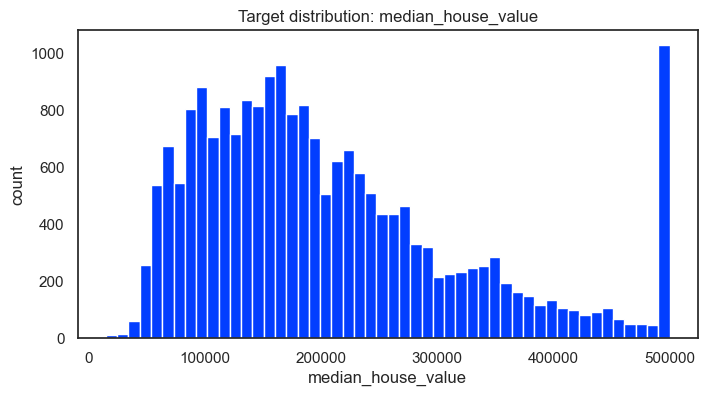

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [10]:
plt.figure(figsize=(8,4))
plt.hist(y, bins=50)
plt.title("Target distribution: median_house_value")
plt.xlabel(TARGET)
plt.ylabel("count")
plt.show()

y.describe()

**Hypothesis:**
- the target look capped (many values at the max)
- it strongly positive-skewed

## 08 — Feature distributions

In [11]:
num_cols = X.select_dtypes(include='number').columns.tolist()
num_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

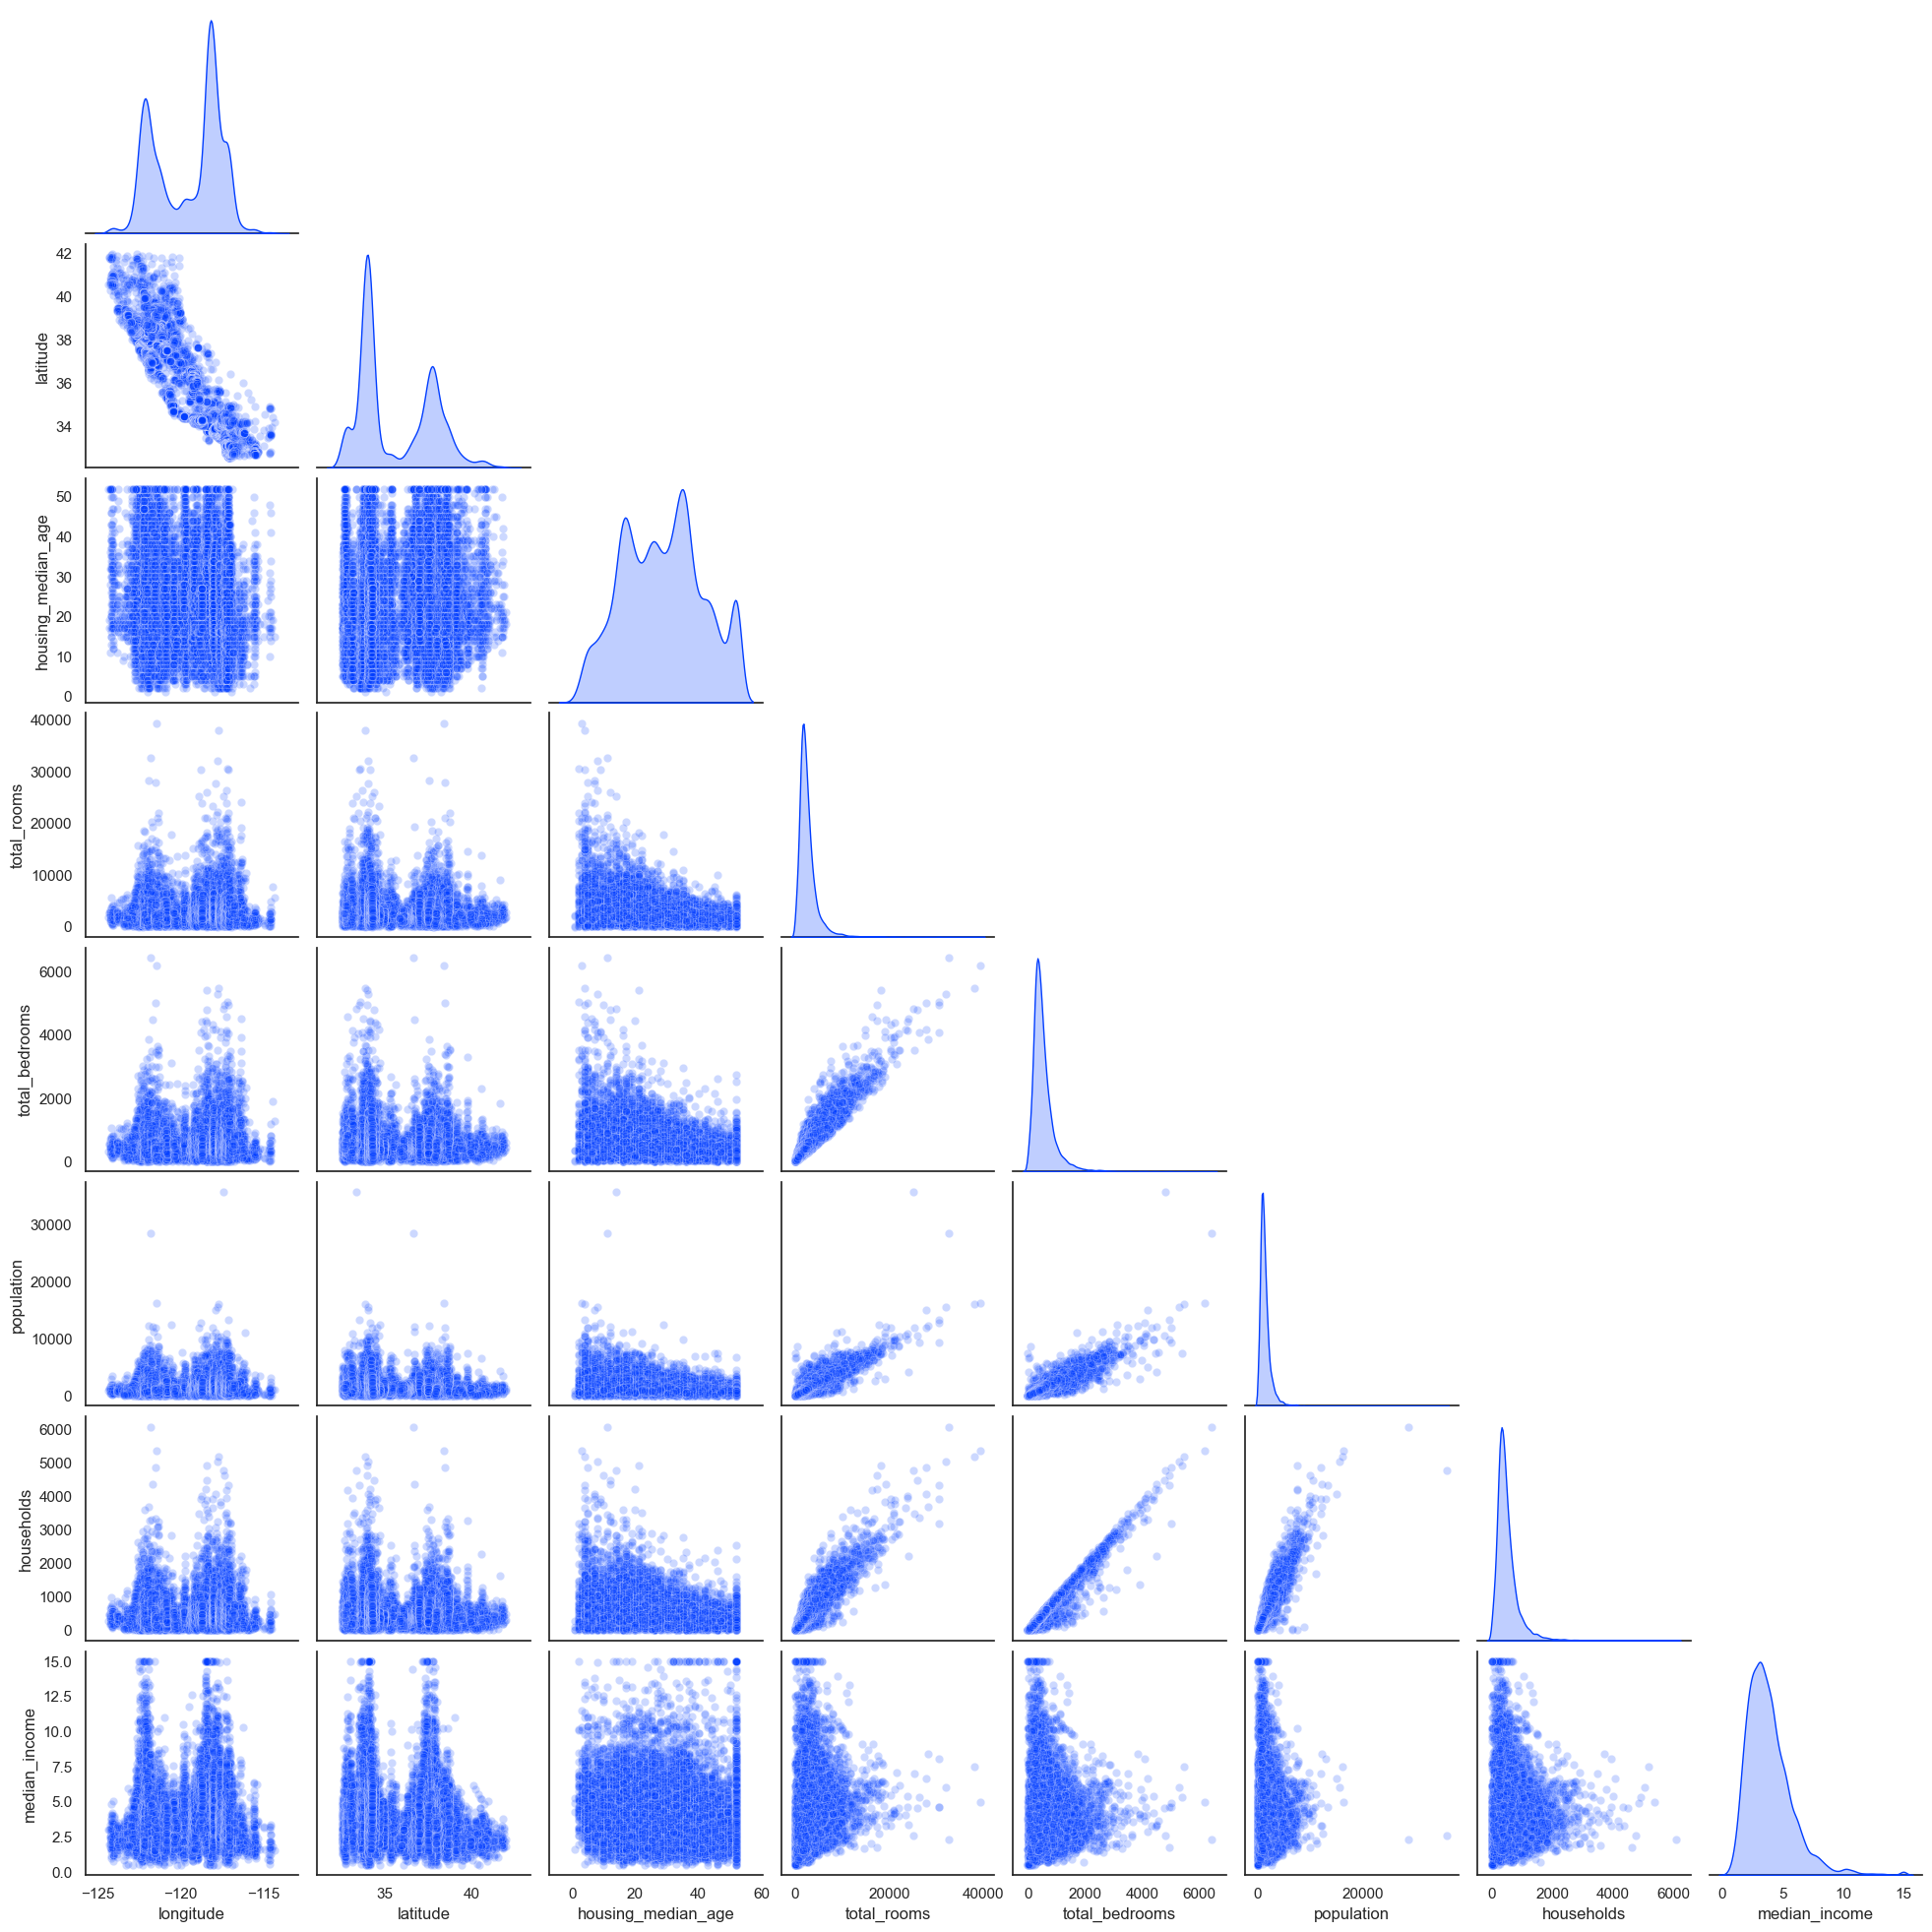

In [12]:
sns.pairplot(df[num_cols], diag_kind="kde", corner=True, plot_kws=dict(alpha=.2))

<Axes: xlabel='median_income'>

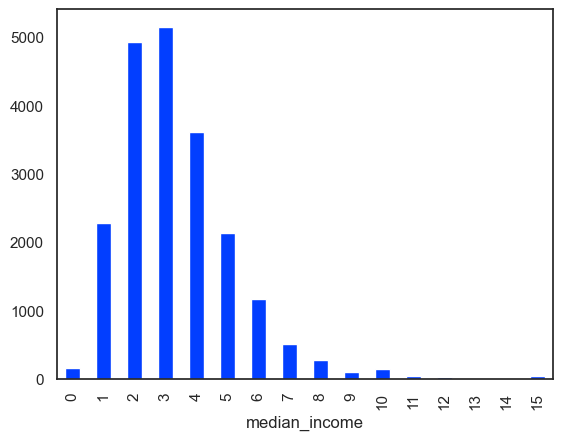

In [13]:
df['median_income'].apply(lambda x: int(x)).value_counts().sort_index().plot(kind='bar')

### 8.1 — Outliers quick scan (quantiles)

In [14]:
df.describe(percentiles=[0.75, 0.90, 0.95, 0.99])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
90%,-117.250000,38.480000,46.000000,4651.500000,965.000000,2566.000000,890.000000,6.159210,376600.000000
95%,-117.080000,38.960000,52.000000,6213.200000,1275.400000,3288.000000,1162.000000,7.300305,489810.000000
99%,-116.290000,40.626100,52.000000,11212.110000,2221.360000,5805.830000,1982.660000,10.596540,500001.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 09 — Correlation analysis

<Axes: >

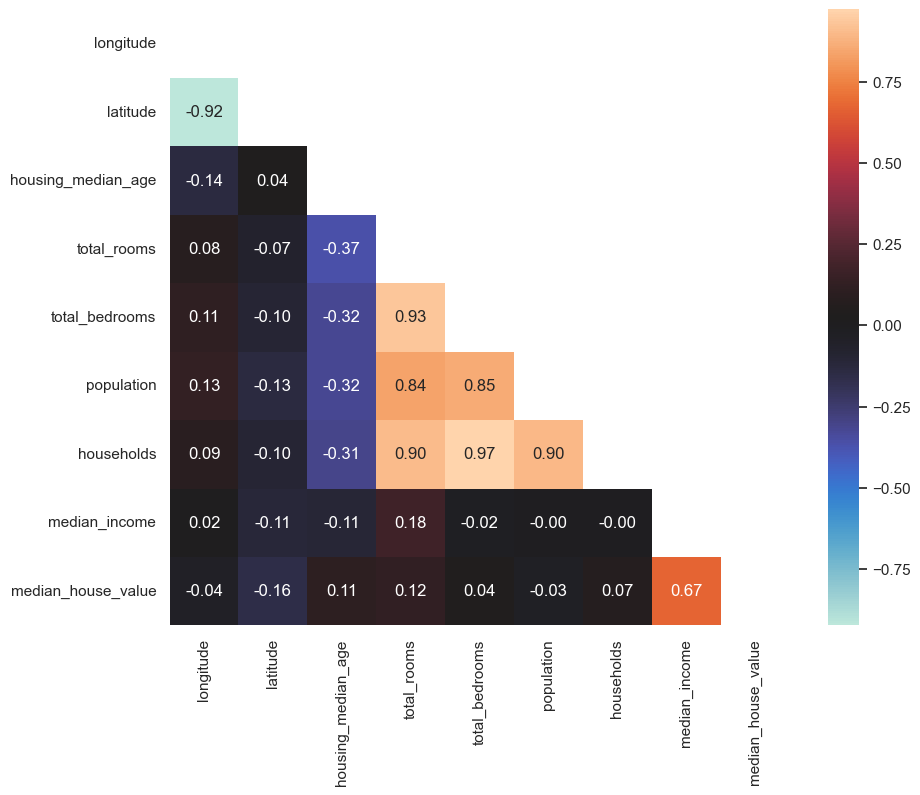

In [15]:
df_sample_num = df.sample(2000, random_state=42).select_dtypes(include='number')

corr = df_sample_num.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr, mask=mask, cmap='icefire', annot=True, fmt='.2f')

In [16]:
corr_with_target = corr[TARGET].sort_values(ascending=False)
corr_with_target

median_house_value    1.000000
median_income         0.671899
total_rooms           0.124199
housing_median_age    0.106338
households            0.067404
total_bedrooms        0.041652
population           -0.033838
longitude            -0.036323
latitude             -0.156292
Name: median_house_value, dtype: float64

In [17]:
threshold = 0.75
pairs = []
cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c = corr.iloc[i, j]
        if abs(c) >= threshold:
            pairs.append((cols[i], cols[j], float(c)))

sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

[('total_bedrooms', 'households', 0.9718825847669262),
 ('total_rooms', 'total_bedrooms', 0.9345603612478705),
 ('longitude', 'latitude', -0.9232326366267539),
 ('total_rooms', 'households', 0.9025485169379955),
 ('population', 'households', 0.8969927992112354),
 ('total_bedrooms', 'population', 0.8534397618017342),
 ('total_rooms', 'population', 0.838369105304783)]

## 10 — Targeted relationship plots

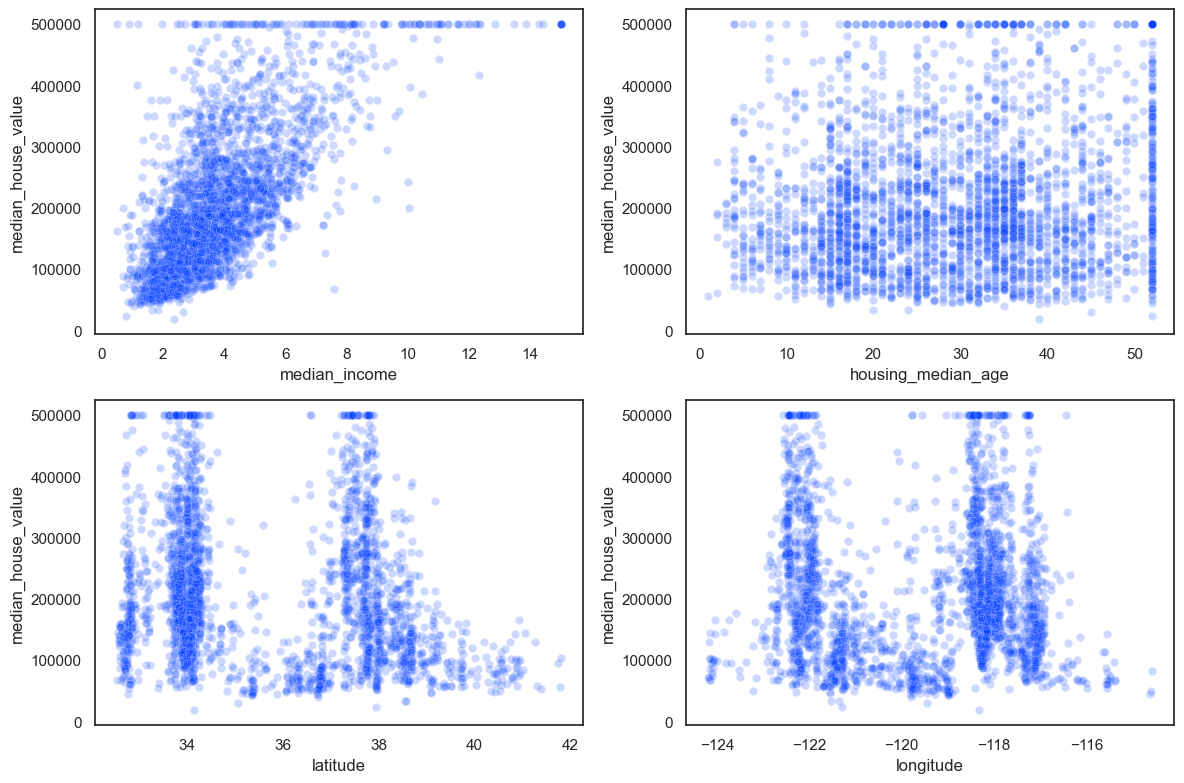

In [18]:
sample = df.sample(n=min(len(df), 3000), random_state=42)

candidates = ["median_income", "housing_median_age", "latitude", "longitude"]

fig, axs = plt.subplots(2, 2, figsize=(12,8))

for ax, column in zip(axs.flatten(), candidates):
    sns.scatterplot(
        data=sample,
        x= column,
        y=TARGET,
        ax=ax,
        alpha=0.2
    )
    
plt.tight_layout()
    
plt.show()

## 11 — Hypotheses (NOT decisions yet)

### Hypotheses to validate later
1) **Feature engineering** improves performance:
   - `population / households`
   - `total_rooms / households`
   - `total_bedrooms / households`
   - `total_bedrooms / total_rooms`


2) **Outlier filtering** (e.g., p99) may improve RMSE — test with/without filtering.

3) **Category cleanup** (`ocean_proximity == "ISLAND"`) may reduce noise — test grouping vs removing.

4) **Binning median_income** could help a linear model. Test vs keeping it continuous.

## 12 — Training plan (MLE)
hand-off to `scripts/train.py` / `src/`.

### 12.1 Target
- **Target:** `median_house_value` (regression)  

### 12.2 Split strategy (conceptual)
- **Train/Test:** 80/20 split  
- **Random seed:** 42

### 12.3 Metrics
- **Primary:** RMSE  
- **Secondary:** MAE  
**Why:** RMSE penalizes large errors more (important for price prediction). MAE is more robust to outliers.

### 12.4 Baseline (must-have)
- **Model:** `DummyRegressor(strategy="mean")`  

### 12.5 Preprocessing
- **Numeric:** `StandardScaler`
- **Categorical:** `StandardScaler` + `OneHotEncoder` + 

### 12.6 First real models
- `LinearRegression`  
- `ElasticNet`  